
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/noahbergam/Desktop/cs-misc/intrinsicDimension/dim-est-env/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/noahbergam/Desktop/cs-misc/intrinsicDimen

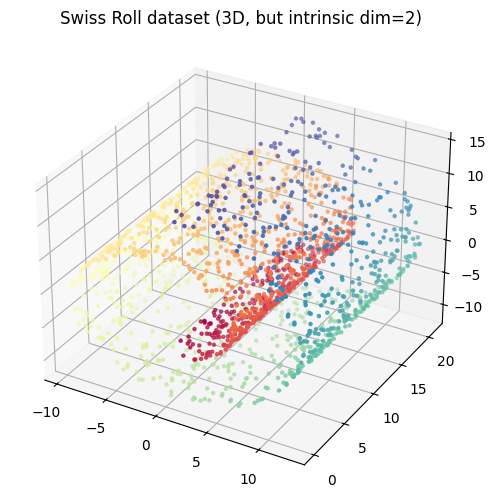

{'MLE': 2.069941772781077,
 'lPCA': 3,
 'KNN': 1,
 'Correlation': 1.9588688728204766,
 'Fisher': 2.879217600547252,
 'MOM': 2.073249148070992,
 'MST': 1.9817966391756772}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
import skdim
from functions import estimate_id_mst

# --- Generate some synthetic high-dimensional data ---
# Swiss roll has intrinsic dimension 2, but is embedded in 3D
X, color = make_swiss_roll(n_samples=2000, noise=0.05)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral, s=5)
ax.set_title("Swiss Roll dataset (3D, but intrinsic dim=2)")
plt.show()

# --- Intrinsic dimension estimation methods ---

def id_ests(X):
    return {'MLE': skdim.id.MLE().fit_transform(X).item(), 
            "lPCA": skdim.id.lPCA().fit_transform(X).item(), 
            "KNN": skdim.id.KNN().fit_transform(X).item(), 
            "Correlation": skdim.id.CorrInt().fit_transform(X).item(),
            "Fisher": skdim.id.FisherS().fit_transform(X).item(),
            "MOM": skdim.id.MOM().fit_transform(X).item(),
            'MST': estimate_id_mst(X, n_subsamples=20,n_repeats=2)['d_hat']}

id_ests(X)


In [17]:
### let's look at grid data
from itertools import product
from functions import *

X = grid_dataset(m=4, d=2, D=8, rotate= True)

id_ests(X)

{'MLE': 1.5830691102610048,
 'lPCA': 2,
 'KNN': 8,
 'Correlation': 1.2341170892038351,
 'Fisher': 1.974022922079353,
 'MOM': 1.4978401073726562,
 'MST': -184.5215452291151}

In [16]:
from tqdm import tqdm

D = 100
n = 300
ds = [i for i in range(2,12)]
pred_ds = []
for d in tqdm(ds):
    m = int(np.log(n) / np.log(d))
    X = grid_dataset(m, d, D, rotate= True)
    pred_ds.append(id_ests(X))

100%|██████████| 10/10 [00:00<00:00, 10.94it/s]


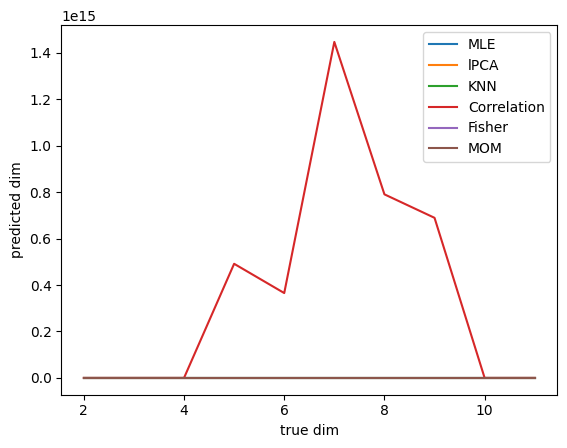

In [17]:
inv_pred_ds = {key: [d[key] for d in pred_ds] for key in pred_ds[0]}
for k in inv_pred_ds.keys():
    plt.plot( ds, inv_pred_ds[k], label=k )
    plt.xlabel('true dim')
    plt.ylabel('predicted dim')
    plt.legend()
#plt.plot( ds, ds, label='truth' )

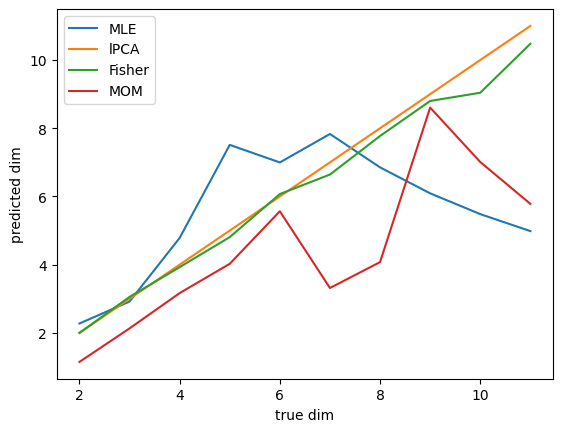

In [18]:
inv_pred_ds = {key: [d[key] for d in pred_ds] for key in pred_ds[0]}
for k in inv_pred_ds.keys():
    if k!= 'Correlation' and k!= 'KNN':
        plt.plot( ds, inv_pred_ds[k], label=k )
        plt.xlabel('true dim')
        plt.ylabel('predicted dim')
        plt.legend()

100%|██████████| 98/98 [01:18<00:00,  1.25it/s]


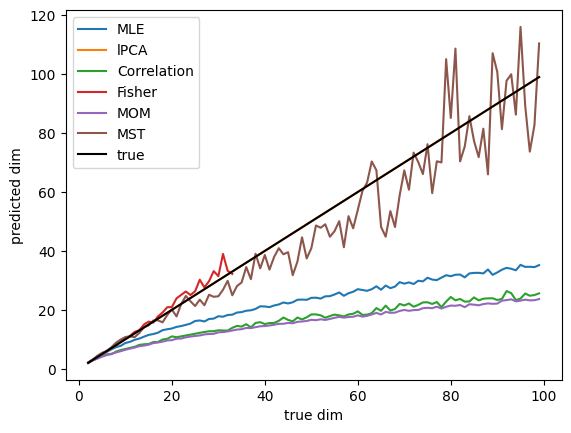

In [18]:

from tqdm import tqdm

D = 200
n = 300
ds = [i for i in range(2,100)]
pred_ds = []
for d in tqdm(ds):
    X = synthetic_subspace(D,d,n,signal_scale=1,noise_scale=0)
    pred_ds.append(id_ests(X))


inv_pred_ds = {key: [d[key] for d in pred_ds] for key in pred_ds[0]}
for k in inv_pred_ds.keys():
    if k!= 'KNN':
        plt.plot( ds, inv_pred_ds[k], label=k )
        plt.xlabel('true dim')
        plt.ylabel('predicted dim')
plt.plot(ds, ds, label='true', c='black')
plt.legend()

100%|██████████| 48/48 [00:37<00:00,  1.27it/s]


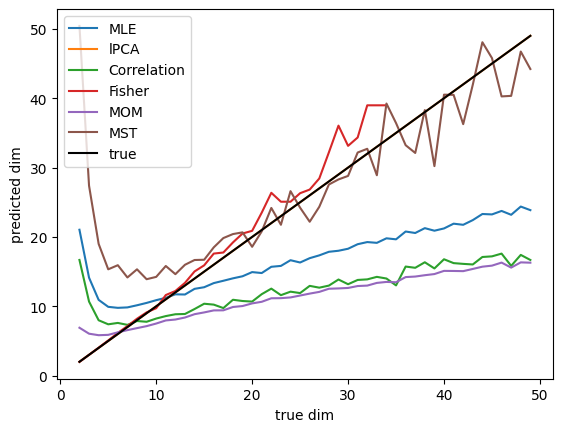

In [20]:

from tqdm import tqdm

D = 200
n = 300
ds = [i for i in range(2,50)]
pred_ds = []
for d in tqdm(ds):
    X = synthetic_subspace(D,d,n, signal_scale=1, noise_scale = 1 / D**0.5)
    pred_ds.append(id_ests(X))


inv_pred_ds = {key: [d[key] for d in pred_ds] for key in pred_ds[0]}
for k in inv_pred_ds.keys():
    if k!= 'KNN':
        plt.plot( ds, inv_pred_ds[k], label=k )
        plt.xlabel('true dim')
        plt.ylabel('predicted dim')
plt.plot(ds, ds, label='true', c='black')
plt.legend()

now let's look at single cell data!

In [2]:
import numpy as np
import scanpy as sc

# PBMC 3k dataset (10x Genomics)
X_pbmc3k = np.asarray( sc.datasets.pbmc3k().X.todense() )

skdim.id.MLE().fit_transform(X_pbmc3k).item()

28.354523085805834

In [3]:
estimate_id_mst(X_pbmc3k, n_subsamples=20,n_repeats=2)['d_hat']

KeyboardInterrupt: 